In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import random
import matplotlib
import warnings

from scipy.interpolate import interp1d
from matplotlib.colors import to_rgb, LinearSegmentedColormap
from scipy.stats import zscore

### Read data tracing data and transcriptional data (Abd-A transcript only)

In [6]:
### First experiment
data_1 = pd.read_csv("../data/Mateo_2019/dnaData_exp1.csv", sep=',')
data_1.drop(['embNumber', 'segNumber', 'brightness'], inplace=True, axis=1)

transc_1 = pd.read_csv("../data/Mateo_2019/rnaData_exp1.csv", sep=',')
transc_1 = transc_1[['cellNumber', 'Abd-A_Intron']]

# Get cell_IDs found in tracing and transcriptional data
transc_ids = set(transc_1['cellNumber'].unique().tolist())
data_ids = set(data_1['cellNumber'].unique().tolist())
unique_ids = transc_ids.intersection(data_ids)

data_1 = data_1[data_1['cellNumber'].isin(unique_ids)]
transc_1 = transc_1[transc_1['cellNumber'].isin(unique_ids)]

### Second experiment
data_2 = pd.read_csv("../data/Mateo_2019/dnaData_exp2.csv", sep=',')
data_2.drop(['embNumber', 'segNumber', 'brightness'], inplace=True, axis=1)

transc_2 = pd.read_csv("../data/Mateo_2019/rnaData_exp2.csv", sep=',')
transc_2 = transc_2[['cellNumber', 'Abd-A_Intron']]

# Get cell_IDs found in tracing and transcriptional data
transc_ids = set(transc_2['cellNumber'].unique().tolist())
data_ids = set(data_2['cellNumber'].unique().tolist())
unique_ids = transc_ids.intersection(data_ids)

data_2 = data_2[data_2['cellNumber'].isin(unique_ids)]
transc_2 = transc_2[transc_2['cellNumber'].isin(unique_ids)]

# Change trace id
data_2['cellNumber'] = data_2['cellNumber']  + data_1['cellNumber'].max()
transc_2['cellNumber'] = transc_2['cellNumber']  + transc_1['cellNumber'].max()

# # Join datasets
ORCA_data = pd.concat([data_1, data_2], axis = 0)
transc_data = pd.concat([transc_1, transc_2], axis = 0)

In [7]:
### Filter region
n_steps = int((ORCA_data['barcode'].max() - ORCA_data['barcode'].min()) + 1)

consec_dist_thr = 5000 # Remove beads located at more than 5000 nm from neighbouring beads

n_traces = len(ORCA_data['cellNumber'].unique())

In [8]:
ORCA_data[ORCA_data['cellNumber']== 1].head(3)

,cellNumber,x,y,z,barcode
0,1,1425.417661,1564.817989,6900.000000,1
1,1,1697.558898,1328.387796,7501.322554,3
2,1,1578.998410,1337.229608,7589.407206,4


### Fill in missing steps

In [9]:
all_barcodes = [*range(1, n_steps+1)]

ORCA_data_array = []
for trace_i in ORCA_data['cellNumber'].unique():
    
    # Find missing barcodes
    ORCA_data_i = ORCA_data[ORCA_data['cellNumber'] == trace_i]
    barcodes_i = ORCA_data_i['barcode'].values.tolist()
    missing_barcodes_i = list(set(all_barcodes) - set(barcodes_i))

    # Create missing rows
    missing_rows_i = np.full((len(missing_barcodes_i), 5), np.nan)
    missing_rows_i[:, 0] = trace_i
    missing_rows_i[:, -1] = missing_barcodes_i

    # Create full array corresponding to current trace
    ORCA_data_array_i = ORCA_data_i.to_numpy().tolist()
    ORCA_data_array_i = ORCA_data_array_i + missing_rows_i.tolist()
    ORCA_data_array = ORCA_data_array + ORCA_data_array_i
            
    if trace_i % 500 == 0:
        print(f"Processed up to trace {trace_i}")

# Convert back into dataframe
ORCA_data = pd.DataFrame(np.array(ORCA_data_array), columns = ORCA_data.columns)
ORCA_data['barcode'] = [int(float(num)) for num in ORCA_data['barcode']]
ORCA_data['cellNumber'] = [int(float(num)) for num in ORCA_data['cellNumber']]
ORCA_data.sort_values(by=['cellNumber', 'barcode'], inplace=True)
ORCA_data.reset_index(inplace=True, drop=True)
ORCA_data = ORCA_data.astype('float32')

Processed up to trace 500
Processed up to trace 1000
Processed up to trace 1500
Processed up to trace 2000
Processed up to trace 2500
Processed up to trace 3000
Processed up to trace 3500
Processed up to trace 4000
Processed up to trace 4500
Processed up to trace 5000
Processed up to trace 5500
Processed up to trace 6000
Processed up to trace 6500
Processed up to trace 7000
Processed up to trace 7500
Processed up to trace 8000
Processed up to trace 8500
Processed up to trace 9000
Processed up to trace 9500
Processed up to trace 10000
Processed up to trace 10500
Processed up to trace 11000
Processed up to trace 11500
Processed up to trace 12000
Processed up to trace 12500
Processed up to trace 13000
Processed up to trace 13500
Processed up to trace 14000
Processed up to trace 14500
Processed up to trace 15000
Processed up to trace 15500
Processed up to trace 16000
Processed up to trace 16500
Processed up to trace 17000
Processed up to trace 17500
Processed up to trace 18000
Processed up

In [10]:
ORCA_data.head()

,cellNumber,x,y,z,barcode
0,1.0,1425.417603,1564.817993,6900.000000,1.0
1,1.0,NaN,NaN,NaN,2.0
2,1.0,1697.558838,1328.387817,7501.322754,3.0
3,1.0,1578.998413,1337.229614,7589.407227,4.0
4,1.0,1508.212524,1346.051636,7524.172852,5.0


#### Filter low efficiency barcodes

In [11]:
# Find barcodes with efficiency < 10 %
ORCA_data['missing'] = np.isnan(ORCA_data['z'])
n_missing = pd.DataFrame(ORCA_data.groupby('barcode').sum()['missing'])
n_missing['perc'] = n_missing['missing'] / n_traces * 100
bad_barcodes = n_missing[n_missing['perc'] > 90].index.tolist()

# Remove barcodes with low efficiency
ORCA_data_filtered = ORCA_data.copy()
for barcode in bad_barcodes:
    ORCA_data_filtered.loc[ORCA_data_filtered['barcode'] == barcode, ['z', 'x', 'y']] = np.nan

#### Calculate percentage of missing barcodes in each trace

In [12]:
missing_perc = ORCA_data_filtered.groupby('cellNumber').sum()['missing'] / n_steps * 100
missing_perc = [int(val) for val in missing_perc.values]
missing_perc_df = pd.DataFrame({'% imaged steps': missing_perc})
missing_perc_df['% imaged steps'] = 100 - missing_perc_df['% imaged steps']

/var/folders/hj/ws1_c53134q8xh5k0ddggyv80000gn/T/ipykernel_41137/1502019009.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([0, 20, 40, 60, 80, 100], size=12)
/var/folders/hj/ws1_c53134q8xh5k0ddggyv80000gn/T/ipykernel_41137/1502019009.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([0, 20, 40, 60, 80, 100], size=12)


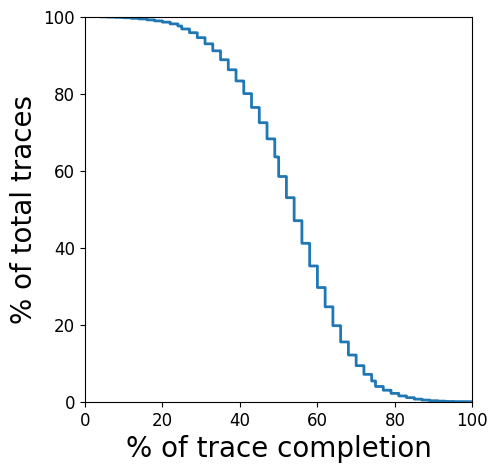

In [13]:
fig, ax = plt.subplots(figsize=(5, 5))

sns.ecdfplot(missing_perc_df, x='% imaged steps', stat='proportion', ax =ax, complementary=True, linewidth=2)

ax.set_xlim(0, 100)
ax.set_ylim(0, 1)
ax.set_yticklabels([0, 20, 40, 60, 80, 100], size=12)
ax.set_xticklabels([0, 20, 40, 60, 80, 100], size=12)
#ax.xaxis.set_minor_locator(MultipleLocator(10))
#ax.yaxis.set_minor_locator(MultipleLocator(0.1))

plt.xlabel('% of trace completion', size=20)
plt.ylabel('% of total traces', size=20)
#plt.grid(visible=None, which='both', axis='both')

plt.show()

#### Remove candidate outliers based on Zscore

In [14]:
ORCA_removed_outliers = []

for trace_index, trace_i in enumerate(ORCA_data_filtered['cellNumber'].unique()):
    data_trace_i = ORCA_data_filtered[ORCA_data_filtered['cellNumber'] == trace_i].copy()

    data_trace_i_zscore = zscore(data_trace_i[['z', 'x', 'y']], 0, nan_policy="omit")
    outlier_rows = np.where(abs(data_trace_i_zscore) > 3)[0].tolist()

    data_trace_i.iloc[outlier_rows, 1:4] = np.nan

    ORCA_removed_outliers.append(data_trace_i)

    if trace_i % 1000 == 0:
            print(f"Processed up to trace {trace_i}")
    
ORCA_removed_outliers = pd.concat(ORCA_removed_outliers, axis=0, ignore_index=True)
ORCA_removed_outliers.reset_index(inplace=True, drop=True)

Processed up to trace 1000.0
Processed up to trace 2000.0
Processed up to trace 3000.0
Processed up to trace 4000.0
Processed up to trace 5000.0
Processed up to trace 6000.0
Processed up to trace 7000.0
Processed up to trace 8000.0
Processed up to trace 9000.0
Processed up to trace 10000.0
Processed up to trace 11000.0
Processed up to trace 12000.0
Processed up to trace 13000.0
Processed up to trace 14000.0
Processed up to trace 15000.0
Processed up to trace 16000.0
Processed up to trace 17000.0
Processed up to trace 18000.0
Processed up to trace 19000.0
Processed up to trace 20000.0
Processed up to trace 21000.0
Processed up to trace 22000.0
Processed up to trace 23000.0
Processed up to trace 24000.0
Processed up to trace 25000.0
Processed up to trace 26000.0
Processed up to trace 27000.0
Processed up to trace 28000.0
Processed up to trace 29000.0
Processed up to trace 30000.0
Processed up to trace 31000.0
Processed up to trace 32000.0
Processed up to trace 33000.0
Processed up to tra

#### Check distribution of distances between consecutive distances

In [15]:
# Convert into matrix
distances = np.zeros((len(ORCA_removed_outliers['cellNumber'].unique()), n_steps, n_steps))

for trace_index, trace_i in enumerate(ORCA_removed_outliers['cellNumber'].unique()):    
    trace_i_data = ORCA_removed_outliers[ORCA_removed_outliers['cellNumber'] == trace_i]
    trace_i_dists_coords = trace_i_data[['x', 'y', 'z']].to_numpy()
    
    distances_i_mat = np.linalg.norm(trace_i_dists_coords[np.newaxis, :, :] - trace_i_dists_coords[:, np.newaxis, :], axis=2)
    distances[trace_index, :, :] = distances_i_mat

In [16]:
# Get all diagonals
all_diags = []
for i in range(0, distances.shape[0]):
    diag_i = np.diagonal(distances[i], offset=1)
    all_diags.append(diag_i)

all_diags = np.concatenate(all_diags).ravel()
all_diags = all_diags[~np.isnan(all_diags)]

print(f'Second quartile starts at {np.percentile(all_diags, 25)}')
print(f'Third quartile ends at {np.percentile(all_diags, 75)}')

Second quartile starts at 101.37220764160156
Third quartile ends at 229.19862365722656


#### Remove barcodes that are too far away from their adjacent ones

In [17]:
ORCA_removed_outliers_extra = []

for trace_index, trace_i in enumerate(ORCA_removed_outliers['cellNumber'].unique()):    
    trace_i_data = ORCA_removed_outliers[ORCA_removed_outliers['cellNumber'] == trace_i]
    trace_i_dists_coords = trace_i_data[['x', 'y', 'z']].to_numpy()

    distances_i_mat = np.linalg.norm(trace_i_dists_coords[np.newaxis, :, :] - trace_i_dists_coords[:, np.newaxis, :], axis=2)

    # Find beads spaced more than chosen distance
    distances_greater = distances_i_mat > consec_dist_thr
    distances_diag_1 = np.diag(distances_greater, k=1)
    distances_diag_2 = np.where(distances_diag_1, True, np.nan)
    distances_diag_3 = np.diff(distances_diag_2)
    
    # Remove first and last 
    if distances_diag_2[0] == 1:
        distances_diag_3[0] = 0
    if distances_diag_2[-1] == 1:
        distances_diag_3[-1] = 0
    bad_beads = np.where(distances_diag_3, False, True)
    bad_beads = list(np.where(bad_beads)[0] + 2)

    # Removed beads from trace
    bad_locs = np.where(trace_i_data['barcode'].isin(bad_beads))[0].tolist()
    trace_i_data.iloc[bad_locs, 1:4] = np.nan
    ORCA_removed_outliers_extra.append(trace_i_data)
    
    if trace_i % 500 == 0:
        print(f"Processed up to trace {trace_i}")
        

ORCA_removed_outliers_extra = pd.concat(ORCA_removed_outliers_extra, axis=0, ignore_index=True)
ORCA_removed_outliers_extra.reset_index(inplace=True, drop=True)
ORCA_removed_outliers_extra['missing'] = (np.isnan(ORCA_removed_outliers_extra['z'])) & (np.isnan(ORCA_removed_outliers_extra['x'])) & (np.isnan(ORCA_removed_outliers_extra['y']))

Processed up to trace 500.0
Processed up to trace 1000.0
Processed up to trace 1500.0
Processed up to trace 2000.0
Processed up to trace 2500.0
Processed up to trace 3000.0
Processed up to trace 3500.0
Processed up to trace 4000.0
Processed up to trace 4500.0
Processed up to trace 5000.0
Processed up to trace 5500.0
Processed up to trace 6000.0
Processed up to trace 6500.0
Processed up to trace 7000.0
Processed up to trace 7500.0
Processed up to trace 8000.0
Processed up to trace 8500.0
Processed up to trace 9000.0
Processed up to trace 9500.0
Processed up to trace 10000.0
Processed up to trace 10500.0
Processed up to trace 11000.0
Processed up to trace 11500.0
Processed up to trace 12000.0
Processed up to trace 12500.0
Processed up to trace 13000.0
Processed up to trace 13500.0
Processed up to trace 14000.0
Processed up to trace 14500.0
Processed up to trace 15000.0
Processed up to trace 15500.0
Processed up to trace 16000.0
Processed up to trace 16500.0
Processed up to trace 17000.0


#### Keep traces with > 95% steps labelled

In [43]:
eff_thr = 0.85

In [44]:
good_traces_indices = np.where(ORCA_removed_outliers_extra[['cellNumber', 'missing']].groupby('cellNumber').sum()['missing'] <= ((1-eff_thr) * n_steps))[0]

good_traces = [ORCA_removed_outliers_extra['cellNumber'].unique()[index] for index in good_traces_indices]
good_traces = ORCA_removed_outliers_extra[ORCA_removed_outliers_extra['cellNumber'].isin(good_traces)]

In [45]:
len(good_traces['cellNumber'].unique())

280

In [46]:
good_traces

,cellNumber,x,y,z,barcode,missing
1768,35.0,1326.714844,1373.578613,7232.300293,1.0,False
1769,35.0,1259.219116,1366.225830,7273.250977,2.0,False
1770,35.0,1335.578491,1344.699707,7149.191406,3.0,False
1771,35.0,1277.525024,1325.178345,7203.950684,4.0,False
1772,35.0,1358.648071,1174.238770,7010.266602,5.0,False
...,...,...,...,...,...,...
2808671,54028.0,1006.275269,1661.771362,7449.744141,48.0,False
2808672,54028.0,986.702881,1757.542114,7501.041504,49.0,False
2808673,54028.0,1015.447998,1651.974487,7629.323242,50.0,False
2808674,54028.0,1022.882812,1643.814209,7501.175293,51.0,False


#### Interpolate missing barcodes

In [47]:
good_traces_interpolated = good_traces.copy()
good_traces_interpolated.reset_index(inplace=True, drop=True)

for index, row in good_traces_interpolated.iterrows(): # Go through all rows
    if np.isnan(row['x']): # Identify if bead is missing
        trace = row['cellNumber']
        barcode = row['barcode']

        # Find closest beads around
        trace_i_data = good_traces_interpolated[good_traces_interpolated['cellNumber'] == trace]
        trace_i_data = trace_i_data.dropna(axis=0)
        trace_i_data['dist'] = (trace_i_data['barcode'] - barcode).astype(int)

        trace_i_data_left = trace_i_data[trace_i_data['dist'] < 0]
        trace_i_data_left = trace_i_data_left.copy()
        trace_i_data_left['dist_abs'] = abs(trace_i_data_left['dist']).values.tolist()
        trace_i_data_right = trace_i_data[trace_i_data['dist'] > 0]
        trace_i_data_right = trace_i_data_right.copy()
        trace_i_data_right['dist_abs'] = abs(trace_i_data_right['dist']).values.tolist()
    
        trace_i_data_close_left = trace_i_data_left.nsmallest(1, 'dist_abs')
        trace_i_data_close_right = trace_i_data_right.nsmallest(1, 'dist_abs')

        if len(trace_i_data_close_left) == 0:
            trace_i_data_close_right = trace_i_data_right.nsmallest(2, 'dist_abs')
        if len(trace_i_data_close_right) == 0:
            trace_i_data_close_left = trace_i_data_left.nsmallest(2, 'dist_abs')

        
        trace_i_data_close = pd.concat([trace_i_data_close_left, trace_i_data_close_right])
        
        # Interpolate
        bead_nums = trace_i_data_close['barcode'].values.tolist()
        x_vals = trace_i_data_close['x'].values.tolist()
        y_vals = trace_i_data_close['y'].values.tolist()
        z_vals = trace_i_data_close['z'].values.tolist()

        f_x = interp1d(bead_nums, x_vals, fill_value="extrapolate")
        f_y = interp1d(bead_nums, y_vals, fill_value="extrapolate")
        f_z = interp1d(bead_nums, z_vals, fill_value="extrapolate")

        x_interp = float(f_x(barcode))
        y_interp = float(f_y(barcode))
        z_interp = float(f_z(barcode))

        good_traces_interpolated.loc[index, ['x', 'y', 'z']] = [x_interp, y_interp, z_interp]

    if (row['cellNumber'] % 500 == 0) & (row['barcode'] == n_steps):
        print(f"Interpolated up to trace {row['cellNumber']}.")

#### Convert into matrix

In [48]:
distances_interpolated = np.zeros((len(good_traces_interpolated['cellNumber'].unique()), n_steps, n_steps))

for trace_index, trace_i in enumerate(good_traces_interpolated['cellNumber'].unique()):    
    trace_i_data = good_traces_interpolated[good_traces_interpolated['cellNumber'] == trace_i]
    trace_i_dists_coords = trace_i_data[['x', 'y', 'z']].to_numpy()
    
    distances_i_mat = np.linalg.norm(trace_i_dists_coords[np.newaxis, :, :] - trace_i_dists_coords[:, np.newaxis, :], axis=2)
    distances_interpolated[trace_index, :, :] = distances_i_mat

    if trace_i % 500 == 0:
        print(f"Processed up to trace {trace_i}")

#### Convert into vector

In [49]:
# Extract values
distances_interpolated_df = []
for mat_num in range(distances_interpolated.shape[0]):
    curr_mat = distances_interpolated[mat_num]
    distances_interpolated_df.append(curr_mat[np.triu_indices(curr_mat.shape[0], 1)].tolist())

# Get column names
col_names = []
for bead_i in range(0, n_steps - 1):
    for bead_j in range(bead_i + 1, n_steps):
        name_i_j = f"{bead_i + 1}-{bead_j+1}"
        col_names.append(name_i_j)

distances_interpolated_df = pd.DataFrame(distances_interpolated_df, columns=col_names)

distances_interpolated_df['cellNumber'] = good_traces_interpolated['cellNumber'].unique().tolist()

#### Format and save

In [50]:
distances_interpolated_df = distances_interpolated_df.iloc[:, [-1] + np.arange(0, distances_interpolated_df.shape[1]-1).tolist()]
transc_data['Abd-A_Intron'] = np.where(transc_data['Abd-A_Intron'] > 0, 1, 0)

distances_interpolated_df.to_csv('../data/Mateo_2019/selected_structures_85_5000_filtered.tsv', sep='\t', index=False)
transc_data.to_csv('../data/Mateo_2019/transcriptional_data_85_5000_filtered.tsv', sep='\t', index=False)

In [51]:
distances_interpolated_df

,cellNumber,1-2,1-3,1-4,1-5,1-6,1-7,1-8,1-9,1-10,...,48-49,48-50,48-51,48-52,49-50,49-51,49-52,50-51,50-52,51-52
0,35.0,79.288681,88.428741,74.605125,300.091766,207.649734,303.103210,192.009323,209.874298,190.879272,...,47.011105,165.331543,141.710098,214.531815,181.835953,133.699020,212.500122,88.726730,307.459503,279.830414
1,79.0,128.214355,256.428711,384.642761,230.550980,143.148743,169.920364,296.868927,381.561279,353.354919,...,142.376999,177.534454,66.152786,89.233009,96.521347,148.030151,104.586975,148.911377,100.806030,81.238655
2,81.0,98.026604,135.625946,193.556610,92.837296,119.545441,218.421600,79.028732,200.363434,166.366241,...,56.854023,177.879181,161.021179,204.066162,176.274139,181.376587,238.912552,71.281471,193.311325,131.592026
3,87.0,122.593307,145.598282,199.969833,330.075348,259.790771,187.178177,282.882690,363.689484,312.459106,...,154.273712,139.996338,157.047363,197.471283,68.067261,136.134521,204.201538,68.067261,136.134277,68.067009
4,91.0,76.085861,143.632263,130.128128,124.722702,140.907669,81.421776,50.233456,136.058594,187.574707,...,69.594894,74.070160,123.387192,322.406464,138.050659,191.534393,365.595367,77.279541,267.444489,298.343933
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
275,53814.0,88.980934,263.182953,157.179413,165.856125,287.692810,264.621063,350.967377,455.189545,331.077515,...,101.335297,172.215927,163.108673,114.832970,92.518211,145.745590,111.636040,230.740280,198.421646,55.754211
276,53909.0,86.705872,143.243088,161.083832,398.066467,386.667816,298.655304,475.539520,194.021500,240.535812,...,98.040459,168.480850,180.230667,198.320358,116.343971,107.609528,139.578186,38.298367,38.142185,46.244007
277,53932.0,96.931931,195.034760,301.915588,281.936035,111.818871,114.264153,104.168976,274.280853,442.391937,...,185.992447,286.189758,399.973541,348.498077,267.629791,387.197052,322.005890,159.088593,67.340355,157.261642
278,53958.0,242.529495,188.007858,174.625229,210.384079,87.933258,165.670364,219.099503,163.882645,309.987915,...,83.453171,118.698257,91.026405,104.093491,96.092270,138.600616,106.810379,104.570122,142.320572,171.754593
